In [ ]:
import os
import sys
import pandas as pd
from typing import Tuple
from PI_score_generator import score_all, _load_lexicons, _PATTERN_CACHE

pd.set_option('display.max_rows', None)  # Show all columns

NameError: name '__file__' is not defined

In [9]:
import os
import sys
import pandas as pd
from typing import Tuple

# In Notebooks, use os.getcwd() to get the current folder path
current_dir = os.getcwd() 
project_root = os.path.abspath(os.path.join(current_dir, "../../"))

# Add to sys.path if not already there
if project_root not in sys.path:
    sys.path.append(project_root)

# Now the import will work
from PI_score_generator import score_all, _load_lexicons, _PATTERN_CACHE

# Pandas display settings
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', None)

# Functions

In [ ]:
def run_expanded_lexicons(use_expanded_lexicons=False):
    filename = "helper_features/lexicons_expanded.json" if use_expanded_lexicons else "helper_features/lexicons.json"
    os.environ["PI_LEXICON_FILE"] = filename
    _load_lexicons.cache_clear()
    _PATTERN_CACHE.clear()

def build_score_matrices(
    df: pd.DataFrame,
    text_col: str = "argument",
    use_expanded_lexicons: bool = False # False or True
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Runs score_all once per row and returns two DataFrames:
    1. df_subfeatures: Every individual metric (e.g., 'Sentiment.anger')
    2. df_means: Only the category-level means (e.g., 'Sentiment.mean')
    """
    run_expanded_lexicons(use_expanded_lexicons)

    rows_sub = []
    rows_mean = []

    for txt in df[text_col].fillna(""):
        # Process the text once per row
        txt = txt.lower()
        scores = score_all(txt)
        
        flat_sub = {}
        flat_mean = {}

        for cat, vals in scores.items():
            if isinstance(vals, dict):
                for subk, v in vals.items():
                    if subk == "mean":
                        # Populate the Mean Matrix
                        flat_mean[f"{cat}.mean"] = v
                    else:
                        # Populate the Sub-feature Matrix
                        flat_sub[f"{cat}.{subk}"] = v
            # Handle overall_mean if it's a direct key in your score_all output
            elif cat == "Overall_mean":
                flat_mean["Overall_mean"] = vals

        rows_sub.append(flat_sub)
        rows_mean.append(flat_mean)

    # Convert to DataFrames and handle numeric conversion/NaNs
    df_subfeatures = pd.DataFrame(rows_sub, index=df.index).apply(pd.to_numeric, errors="coerce").fillna(0.0)
    df_means = pd.DataFrame(rows_mean, index=df.index).apply(pd.to_numeric, errors="coerce").fillna(0.0)

    return df_subfeatures, df_means

In [3]:
# Newly added function to score a single argument and return both sub-feature and mean scores
def score_single_argument(
    text: str,
    use_expanded_lexicons: bool = False
):
    df = pd.DataFrame({"argument": [text]})
    df_sub, df_mean = build_score_matrices(
        df,
        use_expanded_lexicons=use_expanded_lexicons
    )
    return df_sub.iloc[0], df_mean.iloc[0]

In [4]:
import numpy as np
import pandas as pd


def calculate_dual_weighted_score(raw_scores: dict, sub_ci_df: pd.DataFrame, mean_ci_df: pd.DataFrame) -> dict:
    """
    Applies empirical weights from two regression levels:
    1. Sub-features (e.g., Sentiment.anger)
    2. Category Means (e.g., Sentiment.mean)
    """
    # Create lookups
    sub_weights = sub_ci_df['coef'].to_dict()
    mean_weights = mean_ci_df['coef'].to_dict()
    
    # We track two different final log-odds paths
    sub_total_log_odds = sub_weights.get("intercept", 0.0)
    mean_total_log_odds = mean_weights.get("intercept", 0.0)
    
    weighted_out = {}

    for cat, subfeatures in raw_scores.items():
        weighted_out[cat] = {}
        
        # A) Apply Sub-feature weights
        for subk, score_val in subfeatures.items():
            if subk == "mean": continue
            
            f_key = f"{cat}.{subk}"
            w = sub_weights.get(f_key, 0.0)
            weighted_val = score_val * w
            weighted_out[cat][subk] = round(weighted_val, 4)
            sub_total_log_odds += weighted_val
            
        # B) Apply Category Mean weight
        raw_mean = subfeatures.get("mean", 0.0)
        m_key = f"{cat}.mean"
        m_weight = mean_weights.get(m_key, 0.0)
        
        weighted_mean_impact = raw_mean * m_weight
        weighted_out[cat]["mean"] = round(weighted_mean_impact, 4)
        mean_total_log_odds += weighted_mean_impact

    # C) Metadata for Final Probability
    weighted_out["metadata"] = {
        "sub_model": {
            "log_odds": round(sub_total_log_odds, 4),
            "prob": round(1 / (1 + np.exp(-sub_total_log_odds)), 4)
        },
        "mean_model": {
            "log_odds": round(mean_total_log_odds, 4),
            "prob": round(1 / (1 + np.exp(-mean_total_log_odds)), 4)
        }
    }
    
    return weighted_out

# TODO: not yet add the expanded lexicons
def get_persuasion_report(text: str) -> tuple:
    """
    Returns two objects:
    1. Raw Linguistic Scores (score_all)
    2. Empirical Weighted Scores using the dual weighting function.
    """
    # 1. Paths to your empirical coefficient files
    SUB_PATH = "helper_features/regression_outputs/ci_ukp_subfeatures.csv"
    MEAN_PATH = "helper_features/regression_outputs/ci_ukp_mean.csv"
    
    # 2. Extract Baseline Features
    raw_scores = score_all(text)
    
    # 3. Check for stored CI files
    if not os.path.exists(SUB_PATH) or not os.path.exists(MEAN_PATH):
        print("Warning: UKP coefficient files not found. Check paths.")
        return raw_scores, None
    
    # 4. Load the coefficients
    ci_ukp_sub = pd.read_csv(SUB_PATH, index_col=0)
    ci_ukp_mean = pd.read_csv(MEAN_PATH, index_col=0)
    
    # 5. Reuse your existing function to perform the math
    # This returns the nested dict with both sub-feature and mean weights
    ukp_weighted = calculate_dual_weighted_score(
        raw_scores=raw_scores,
        sub_ci_df=ci_ukp_sub,
        mean_ci_df=ci_ukp_mean
    )
    
    return raw_scores, ukp_weighted

# Test multiple arguments

In [5]:
import pandas as pd
# Evidence-heavy + Authority + Specificity
sub, mean = score_single_argument(
    "According to the World Health Organization, over 75% of adults experience significant stress at least once per year. A recent 2023 study conducted by researchers at Harvard University found that individuals who engage in regular physical activity reduce their stress levels by approximately 30% within three months. These findings suggest that even small, consistent changes—such as walking 2 kilometers at the end of the day per day—can have measurable benefits for mental health.",
    use_expanded_lexicons=False
)

# print(sub[sub > 0].sort_values(ascending=False))
print(sub[sub==0])

Specificity.interactional_immediacy      0.0
Authority/Credibility.titles             0.0
Opponent’s View.acknowledge              0.0
Opponent’s View.refutation_strength      0.0
Sentiment.anger                          0.0
Sentiment.sadness                        0.0
Politeness.professional_courtesy         0.0
Politeness.rapport_building              0.0
Politeness.domineering                   0.0
Reciprocity.direct_promise               0.0
Reciprocity.mutual_benefit               0.0
Reciprocity.concession_framing           0.0
Impact.loss_framing                      0.0
Impact.threat_severity                   0.0
Commitment.statements                    0.0
Commitment.power                         0.0
Scarcity/Urgency.exclusivity_quantity    0.0
Engagement.identification                0.0
Engagement.self_reference                0.0
Engagement.inquiry                       0.0
Engagement.imagery                       0.0
Propaganda.emotional_charge              0.0
Propaganda

In [6]:
sub, mean = score_single_argument(
    "According to the World Health Organization, over 75% of adults experience significant stress at least once per year. A recent 2023 study conducted by researchers at Harvard University found that individuals who engage in regular physical activity reduce their stress levels by approximately 30% within three months. These findings suggest that even small, consistent changes—such as walking 2 kilometers at the end of the day per day—can have measurable benefits for mental health.",
    use_expanded_lexicons=True
)

print(sub[sub > 0].sort_values(ascending=False))

Evidence.attribution                     1.000000
Specificity.psychological_nearness       1.000000
Style.fluency                            1.000000
Authority/Credibility.phrases            1.000000
Authority/Credibility.consensus          1.000000
Impact.future_projection                 1.000000
Impact.gain_framing                      1.000000
Argumentation.premise_density            1.000000
Politeness.non_imposition                1.000000
Evidence.named_entities                  0.991451
Evidence.statistical                     0.971884
Authority/Credibility.organizations      0.971884
Logic/Cohesion.structural_reasoning      0.907538
Scarcity/Urgency.temporal_urgency        0.832323
Sentiment.language_intensity             0.832323
Logic/Cohesion.discourse_cohesion        0.832323
Sentiment.fear_threat                    0.695924
Sentiment.joy_gain                       0.695924
Style.length                             0.634664
Sentiment.valence                        0.577073


In [7]:
import pandas as pd

# Emotional + Urgency + Persuasion
sub, mean = score_single_argument(
    "This is not just a minor issue—it is a serious and immediate threat to everything we care about. If we fail to act now, the consequences could be devastating for future generations. Imagine a world where clean air is no longer guaranteed and safe water becomes a luxury. We cannot afford to wait. We must act now before it is too late.",
    use_expanded_lexicons=False
)

# print(sub[sub > 0].sort_values(ascending=False))
print(sub[sub==0])

Evidence.statistical                     0.0
Evidence.attribution                     0.0
Evidence.named_entities                  0.0
Specificity.interactional_immediacy      0.0
Authority/Credibility.titles             0.0
Authority/Credibility.organizations      0.0
Authority/Credibility.phrases            0.0
Authority/Credibility.consensus          0.0
Logic/Cohesion.discourse_cohesion        0.0
Argumentation.premise_density            0.0
Opponent’s View.acknowledge              0.0
Opponent’s View.refutation_strength      0.0
Politeness.professional_courtesy         0.0
Politeness.rapport_building              0.0
Reciprocity.direct_promise               0.0
Reciprocity.mutual_benefit               0.0
Reciprocity.concession_framing           0.0
Impact.gain_framing                      0.0
Commitment.statements                    0.0
Commitment.power                         0.0
Engagement.self_reference                0.0
Engagement.inquiry                       0.0
Engagement

In [8]:
original = ['tons', 'p-value', 'mph', 'ft', 'jpy', 'l', 'hz', 'coefficient', 'ppm', 'km', 'liter', 'significant', 'percent', 'pixels', 'ton', 'index', 'billion', 'thousand', 'in', 'oz', 'db', 'ratio', 'g', 'kg', 'cm', 'mi', 'mm', 'percentage', 'watts', 'mb', 'eur', 'currency', '%', 'lb', 'gbp', 'v', 'mg', 'usd', 'gb', 'litre', 'tb', 'dpi', 'm', 'points', 'million', 'ppb', 'ml', 'kph']
expanded = ['megawatt', 'calories', 'tons', 'lumen', 'kilowatt', 'p-value', 'mph', 'jpy', 'coefficient', 'ft', 'hz', 'l', 'liter', 'ppm', 'km', 'significant', 'quart', 'percent', 'pixels', 'ton', 'index', 'billion', 'thousand', 'hectare', 'nanometer', 'in', 'oz', 'db', 'acre', 'ratio', 'kg', 'g', 'teraflop', 'cm', 'mi', 'mm', 'percentage', 'watts', 'eur', 'mb', 'currency', 'joules', '%', 'lb', 'gbp', 'gigahertz', 'v', 'mg', 'usd', 'gb', 'litre', 'tb', 'points', 'dpi', 'm', 'kilobyte', 'terabyte', 'million', 'decibel', 'ppb', 'gallon', 'ml', 'kph']
print(len(original), len(expanded))

48 63


In [9]:
# Politeness + Indirect Persuasion
sub, mean = score_single_argument(
    "Hi everyone, I just wanted to share a quick thought. Would you be open to considering a small change in how we approach this problem? It might be helpful to try a slightly different strategy, especially since we have already seen some limitations with the current approach. I would really appreciate your feedback on this, and I think together we can find a better solution.",
    use_expanded_lexicons=False
)

# print(sub[sub > 0].sort_values(ascending=False))
print(sub[sub==0])

Evidence.attribution                   0.0
Evidence.named_entities                0.0
Authority/Credibility.titles           0.0
Authority/Credibility.organizations    0.0
Authority/Credibility.phrases          0.0
Authority/Credibility.consensus        0.0
Sentiment.fear_threat                  0.0
Sentiment.anger                        0.0
Sentiment.sadness                      0.0
Politeness.domineering                 0.0
Reciprocity.direct_promise             0.0
Impact.loss_framing                    0.0
Impact.threat_severity                 0.0
Impact.future_projection               0.0
Propaganda.emotional_charge            0.0
Propaganda.logical_distortion          0.0
Name: 0, dtype: float64


In [10]:
# Specificity + Concrete Details
sub, mean = score_single_argument(
    "The package was delivered at 3:45 PM on Tuesday and left at the front door of the building on 5th Avenue. Inside the box, there were three items: a 2 kg steel tool, a set of four replacement parts, and a printed instruction manual. Each component was individually wrapped in plastic and labeled with a serial number.",
    use_expanded_lexicons=False
)

# print(sub[sub > 0].sort_values(ascending=False))
print(sub[sub==0])

Evidence.attribution                     0.0
Specificity.interactional_immediacy      0.0
Authority/Credibility.titles             0.0
Authority/Credibility.organizations      0.0
Authority/Credibility.phrases            0.0
Authority/Credibility.consensus          0.0
Logic/Cohesion.structural_reasoning      0.0
Logic/Cohesion.discourse_cohesion        0.0
Argumentation.conclusion_explicitness    0.0
Argumentation.premise_density            0.0
Argumentation.style_sophistication       0.0
Opponent’s View.acknowledge              0.0
Opponent’s View.refutation_strength      0.0
Sentiment.language_intensity             0.0
Sentiment.fear_threat                    0.0
Sentiment.joy_gain                       0.0
Sentiment.anger                          0.0
Sentiment.sadness                        0.0
Politeness.professional_courtesy         0.0
Politeness.rapport_building              0.0
Politeness.non_imposition                0.0
Politeness.domineering                   0.0
Reciprocit

In [11]:
# Rapport + Friendly Tone
sub, mean = score_single_argument(
    "Hey! Thanks so much for taking the time to read this. I really appreciate your support and everything you’ve contributed so far. It’s been great working together, and I’m excited about what we can accomplish next. Let’s keep building on this momentum!",
    use_expanded_lexicons=False
)

print(sub[sub > 0].sort_values(ascending=False))
# print(sub[sub==0])

Politeness.professional_courtesy         1.000000
Argumentation.premise_density            1.000000
Impact.gain_framing                      1.000000
Reciprocity.mutual_benefit               1.000000
Politeness.non_imposition                1.000000
Politeness.rapport_building              1.000000
Commitment.statements                    1.000000
Impact.future_projection                 1.000000
Specificity.interactional_immediacy      1.000000
Style.fluency                            1.000000
Specificity.psychological_nearness       1.000000
Sentiment.joy_gain                       0.988487
Engagement.characters                    0.988487
Sentiment.vader_compound                 0.956800
Logic/Cohesion.structural_reasoning      0.931339
Engagement.identification                0.931339
Sentiment.language_intensity             0.892702
Engagement.self_reference                0.832323
Logic/Cohesion.discourse_cohesion        0.832323
Scarcity/Urgency.temporal_urgency        0.832323


In [12]:
# Strong Directive / High Persuasive Force
sub, mean = score_single_argument(
    "You need to make this decision today. Delaying any further will only increase the risks and make the situation harder to control. Take action now, follow the recommended steps, and ensure that the problem is addressed immediately. This is the most effective way to prevent further damage.",
    use_expanded_lexicons=False
)

print(sub[sub > 0].sort_values(ascending=False))
# print(sub[sub==0])

Impact.future_projection                 1.000000
Style.fluency                            1.000000
Impact.loss_framing                      1.000000
Authority/Credibility.speech_power       1.000000
Politeness.domineering                   1.000000
Specificity.psychological_nearness       1.000000
Scarcity/Urgency.temporal_urgency        0.998645
Sentiment.language_intensity             0.997613
Logic/Cohesion.discourse_cohesion        0.940998
Logic/Cohesion.structural_reasoning      0.940998
Specificity.interactional_immediacy      0.854975
Engagement.characters                    0.610697
Argumentation.conclusion_explicitness    0.610697
Sentiment.fear_threat                    0.610697
Sentiment.sadness                        0.610697
Engagement.self_reference                0.610697
Scarcity/Urgency.exclusivity_quantity    0.610697
Evidence.named_entities                  0.610697
Style.length                             0.569855
Sentiment.valence                        0.565250


In [13]:
# Balanced Argument (good for sanity check)
sub, mean = score_single_argument(
    "There are both advantages and disadvantages to this approach. On the one hand, it can improve efficiency and reduce costs in the short term. On the other hand, it may introduce new risks that need to be carefully managed. Ultimately, the best decision will depend on how these trade-offs are evaluated in the specific context.",
    use_expanded_lexicons=False
)

# print(sub[sub > 0].sort_values(ascending=False))
print(sub[sub==0])

Evidence.attribution                     0.0
Evidence.named_entities                  0.0
Specificity.interactional_immediacy      0.0
Authority/Credibility.titles             0.0
Authority/Credibility.organizations      0.0
Authority/Credibility.phrases            0.0
Authority/Credibility.consensus          0.0
Sentiment.anger                          0.0
Politeness.professional_courtesy         0.0
Politeness.rapport_building              0.0
Reciprocity.direct_promise               0.0
Reciprocity.mutual_benefit               0.0
Reciprocity.concession_framing           0.0
Impact.threat_severity                   0.0
Commitment.statements                    0.0
Commitment.power                         0.0
Scarcity/Urgency.exclusivity_quantity    0.0
Engagement.identification                0.0
Engagement.self_reference                0.0
Engagement.inquiry                       0.0
Engagement.past                          0.0
Engagement.imagery                       0.0
Engagement

In [14]:
# Mixed Strategy (REALISTIC persuasive argument)
sub, mean = score_single_argument(
    "According to recent reports from the United Nations, global temperatures have already increased by more than 1.1 degrees Celsius since pre-industrial times. This is not just a statistic—it represents real and irreversible damage to ecosystems around the world. If we continue on this path, millions of people could face severe consequences, including food shortages and displacement. We have the tools and knowledge to change this trajectory, but we must act now. Even small actions, such as reducing daily energy consumption or supporting sustainable policies, can make a meaningful difference.",
    use_expanded_lexicons=False
)

print(sub[sub > 0].sort_values(ascending=False))

Impact.future_projection                 1.000000
Politeness.domineering                   1.000000
Specificity.psychological_nearness       1.000000
Style.fluency                            1.000000
Impact.threat_severity                   1.000000
Authority/Credibility.phrases            1.000000
Impact.loss_framing                      1.000000
Evidence.attribution                     1.000000
Impact.gain_framing                      1.000000
Argumentation.premise_density            1.000000
Politeness.non_imposition                1.000000
Commitment.statements                    1.000000
Sentiment.language_intensity             0.974758
Logic/Cohesion.structural_reasoning      0.940998
Evidence.named_entities                  0.909630
Logic/Cohesion.discourse_cohesion        0.848443
Argumentation.style_sophistication       0.848443
Scarcity/Urgency.temporal_urgency        0.848443
Sentiment.vader_compound                 0.807400
Engagement.identification                0.757097


In [15]:
# Wrong spelling
sub, mean = score_single_argument(
    "Thee ae bth advantages and disadvantages to this approach. On the one hand, it can improve efficiency and reduce costs in the short term. On the other hand, it may introduce new risks that need to be carefully managed. Ultimately, the best decision will depend on how these trade-offs are evaluated in the specific context.",
    use_expanded_lexicons=False
)

# print(sub[sub > 0].sort_values(ascending=False))
print(sub[sub==0])

Evidence.attribution                     0.0
Evidence.named_entities                  0.0
Authority/Credibility.titles             0.0
Authority/Credibility.organizations      0.0
Authority/Credibility.phrases            0.0
Authority/Credibility.consensus          0.0
Sentiment.anger                          0.0
Politeness.professional_courtesy         0.0
Politeness.rapport_building              0.0
Reciprocity.direct_promise               0.0
Reciprocity.mutual_benefit               0.0
Reciprocity.concession_framing           0.0
Impact.threat_severity                   0.0
Commitment.statements                    0.0
Commitment.power                         0.0
Scarcity/Urgency.exclusivity_quantity    0.0
Engagement.identification                0.0
Engagement.inquiry                       0.0
Engagement.past                          0.0
Engagement.imagery                       0.0
Propaganda.emotional_charge              0.0
Propaganda.logical_distortion            0.0
Propaganda

# Single comparison

In [16]:
text1 = "Banning single-use plastics is a necessary step if we want to meaningfully reduce environmental damage in our city. Every year, Americans generate over 35 million tons of plastic waste, and less than 10% is successfully recycled. Much of the rest ends up in landfills or waterways, where it breaks down into microplastics that contaminate drinking water and harm marine life. Cities like San Francisco and Seattle have already implemented similar bans and seen measurable reductions in plastic waste without harming local businesses. This policy is not about inconvenience—it’s about long-term public health and sustainability. By transitioning to reusable alternatives, we reduce pollution, protect ecosystems, and lower cleanup costs that taxpayers ultimately bear. If we act now, we can prevent further damage and set a precedent for responsible consumption."

text2 = "We should probably ban single-use plastics because they are bad for the environment. There is a lot of plastic everywhere and it doesn’t look good. People throw things away and it just piles up, which is not great. Other places have done bans too, so maybe we should as well. It might help reduce waste, and using reusable things could be better. Overall, banning plastics seems like a good idea and could improve things somewhat."

raw_scores_1, ukp_weighted_1 = get_persuasion_report(text1)
raw_scores_2, ukp_weighted_2 = get_persuasion_report(text2)

print(ukp_weighted_1['metadata']['sub_model']['prob'],
      ukp_weighted_1['metadata']['mean_model']['prob'])

print(ukp_weighted_2['metadata']['sub_model']['prob'],
      ukp_weighted_2['metadata']['mean_model']['prob'])

0.7548 0.6927
0.7164 0.6894


In [17]:
import pandas as pd
import numpy as np

def compare_reports_by_category(raw_scores_1, ukp_weighted_1, raw_scores_2, ukp_weighted_2):
    rows = []

    # all categories appearing in either report
    categories = sorted(set(raw_scores_1.keys()) | set(raw_scores_2.keys()))

    for cat in categories:
        raw_cat_1 = raw_scores_1.get(cat, {})
        raw_cat_2 = raw_scores_2.get(cat, {})
        weighted_cat_1 = ukp_weighted_1.get(cat, {})
        weighted_cat_2 = ukp_weighted_2.get(cat, {})

        # all subfeatures appearing in either raw/weighted dict
        subkeys = sorted(
            set(raw_cat_1.keys()) | set(raw_cat_2.keys()) |
            set(weighted_cat_1.keys()) | set(weighted_cat_2.keys())
        )

        for subk in subkeys:
            rows.append({
                "category": cat,
                "subfeature": subk,
                "raw_text1": raw_cat_1.get(subk, np.nan),
                "raw_text2": raw_cat_2.get(subk, np.nan),
                "raw_diff_1_minus_2": (
                    raw_cat_1.get(subk, np.nan) - raw_cat_2.get(subk, np.nan)
                    if pd.notna(raw_cat_1.get(subk, np.nan)) and pd.notna(raw_cat_2.get(subk, np.nan))
                    else np.nan
                ),
                "weighted_text1": weighted_cat_1.get(subk, np.nan),
                "weighted_text2": weighted_cat_2.get(subk, np.nan),
                "weighted_diff_1_minus_2": (
                    weighted_cat_1.get(subk, np.nan) - weighted_cat_2.get(subk, np.nan)
                    if pd.notna(weighted_cat_1.get(subk, np.nan)) and pd.notna(weighted_cat_2.get(subk, np.nan))
                    else np.nan
                ),
            })

    df = pd.DataFrame(rows)
    return df

In [18]:
df_compare = compare_reports_by_category(
    raw_scores_1, ukp_weighted_1,
    raw_scores_2, ukp_weighted_2
)

df_compare

,category,subfeature,raw_text1,raw_text2,raw_diff_1_minus_2,weighted_text1,weighted_text2,weighted_diff_1_minus_2
0,Argumentation,conclusion_explicitness,0.281885,0.965637,-0.683752,0.0330,0.1131,-0.0801
1,Argumentation,mean,0.303854,0.880176,-0.576322,0.0453,0.1313,-0.0860
2,Argumentation,premise_density,0.000000,1.000000,-1.000000,-0.0000,-0.0058,0.0058
3,Argumentation,style_sophistication,0.629676,0.674891,-0.045215,0.0079,0.0084,-0.0005
4,Authority/Credibility,consensus,0.000000,0.000000,0.000000,0.0000,0.0000,0.0000
5,Authority/Credibility,mean,0.103138,0.000414,0.102724,0.0036,0.0000,0.0036
6,Authority/Credibility,organizations,0.000000,0.000000,0.000000,0.0000,0.0000,0.0000
7,Authority/Credibility,phrases,0.000000,0.000000,0.000000,-0.0000,-0.0000,0.0000
8,Authority/Credibility,speech_power,0.515689,0.002071,0.513618,-0.0903,-0.0004,-0.0899
9,Authority/Credibility,titles,0.000000,0.000000,0.000000,0.0000,0.0000,0.0000


# Lexicon validation

In [43]:
def build_score_matrices_no_lexicon_specific(
    df: pd.DataFrame,
    text_col: str = "argument"
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Runs score_all once per row and returns two DataFrames:
    1. df_subfeatures: Every individual metric (e.g., 'Sentiment.anger')
    2. df_means: Only the category-level means (e.g., 'Sentiment.mean')
    """
    # run_expanded_lexicons(use_expanded_lexicons)

    rows_sub = []
    rows_mean = []

    for txt in df[text_col].fillna(""):
        # Process the text once per row
        txt = txt.lower()
        scores = score_all(txt)
        
        flat_sub = {}
        flat_mean = {}

        for cat, vals in scores.items():
            if isinstance(vals, dict):
                for subk, v in vals.items():
                    if subk == "mean":
                        # Populate the Mean Matrix
                        flat_mean[f"{cat}.mean"] = v
                    else:
                        # Populate the Sub-feature Matrix
                        flat_sub[f"{cat}.{subk}"] = v
            # Handle overall_mean if it's a direct key in your score_all output
            elif cat == "Overall_mean":
                flat_mean["Overall_mean"] = vals

        rows_sub.append(flat_sub)
        rows_mean.append(flat_mean)

    # Convert to DataFrames and handle numeric conversion/NaNs
    df_subfeatures = pd.DataFrame(rows_sub, index=df.index).apply(pd.to_numeric, errors="coerce").fillna(0.0)
    df_means = pd.DataFrame(rows_mean, index=df.index).apply(pd.to_numeric, errors="coerce").fillna(0.0)

    return df_subfeatures, df_means

# Newly added function to score a single argument and return both sub-feature and mean scores
def score_single_argument_no_lexicon_specific(
    text: str
):
    df = pd.DataFrame({"argument": [text]})
    df_sub, df_mean = build_score_matrices_no_lexicon_specific(
        df
    )
    return df_sub.iloc[0], df_mean.iloc[0]

In [44]:
import json

import random

def _split_value(v):
    """Randomly shuffle and then split into (first_half, second_half)."""
    if isinstance(v, list):
        # Create a copy so you don't mutate the original data
        temp_list = list(v) 
        random.shuffle(temp_list)
        mid = len(temp_list) // 2
        return temp_list[:mid], temp_list[mid:]
    
    elif isinstance(v, dict):
        first, second = {}, {}
        for subk, subv in v.items():
            temp_sublist = list(subv)
            random.shuffle(temp_sublist)
            mid = len(temp_sublist) // 2
            first[subk] = temp_sublist[:mid]
            second[subk] = temp_sublist[mid:]
        return first, second

def split_lexicons_expanded(
    src_path: str = "helper_features/lexicons_expanded_LLM_audited.json",
    out_dir: str = "lexicons/lexicon_validation/half_samples",
    out_name_1: str = "lexicons_sample_1.json",
    out_name_2: str = "lexicons_sample_2.json",
) -> None:
    """
    Splits each word list in lexicons_expanded.json into first and second halves.
    Dict-of-lists values (e.g. ARG_STYLE, SENT_INTENSITY) are split per sub-key.
    Saves lexicons_sample_1.json (first halves) and lexicons_sample_2.json (second halves)
    into out_dir.
    """
    with open(src_path) as f:
        data = json.load(f)

    first_half, second_half = {}, {}
    for key, words in data.items():
        first_half[key], second_half[key] = _split_value(words)

    os.makedirs(out_dir, exist_ok=True)
    with open(os.path.join(out_dir, out_name_1), "w") as f:
        json.dump(first_half, f, indent=2)
    with open(os.path.join(out_dir, out_name_2), "w") as f:
        json.dump(second_half, f, indent=2)

    print(f"Saved {out_name_1} and {out_name_2} to '{out_dir}/'")
    for key in list(data.keys())[:3]:
        v = data[key]
        n = len(v) if isinstance(v, list) else sum(len(sv) for sv in v.values())
        n1 = len(first_half[key]) if isinstance(first_half[key], list) else sum(len(sv) for sv in first_half[key].values())
        n2 = len(second_half[key]) if isinstance(second_half[key], list) else sum(len(sv) for sv in second_half[key].values())
        print(f"  {key}: {n} -> {n1} / {n2}")
    print(f"  ... ({len(data)} keys total)")

split_lexicons_expanded()

Saved lexicons_sample_1.json and lexicons_sample_2.json to 'lexicons/lexicon_validation/half_samples/'
  ARG_CLAIM: 132 -> 66 / 66
  ARG_CONCLUSION: 65 -> 32 / 33
  ARG_PREMISE: 79 -> 39 / 40
  ... (57 keys total)


In [ ]:
from PI_score_generator import _PATTERN_CACHE

def score_with_sample(sample_path: str, text: str):
    os.environ["PI_LEXICON_FILE"] = os.path.abspath(sample_path)
    _load_lexicons.cache_clear()   # reloads word sets from JSON
    _PATTERN_CACHE.clear()         # forces regex recompile from the new word sets
    return score_single_argument_no_lexicon_specific(text)

test_text = (
    "According to the World Health Organization, over 75% of adults experience significant stress "
    "at least once per year. A recent 2023 study conducted by researchers at Harvard University found "
    "that individuals who engage in regular physical activity reduce their stress levels by approximately "
    "30% within three months. These findings suggest that even small, consistent changes—such as walking "
    "2 kilometers at the end of the day per day—can have measurable benefits for mental health."
)

sub1, mean1 = score_with_sample("half_samples/lexicons_sample_1.json", test_text)
sub2, mean2 = score_with_sample("half_samples/lexicons_sample_2.json", test_text)

df_sub_compare = pd.DataFrame({
    "sample_1": sub1,
    "sample_2": sub2,
    "diff (1-2)": sub1 - sub2,
}).sort_values("diff (1-2)", key=abs, ascending=False)

df_mean_compare = pd.DataFrame({
    "sample_1": mean1,
    "sample_2": mean2,
    "diff (1-2)": mean1 - mean2,
}).sort_values("diff (1-2)", key=abs, ascending=False)

print("=== Sub-feature comparison ===")
display(df_sub_compare)
print("\n=== Mean comparison ===")
display(df_mean_compare)

In [11]:
import pandas as pd
# Evidence-heavy + Authority + Specificity
sub, mean = score_single_argument(
    test_text,
    use_expanded_lexicons=True
)

# print(sub[sub > 0].sort_values(ascending=False))
mean

Loading lexicons from: helper_features/lexicons_expanded.json


Evidence.mean                 0.980155
Specificity.mean              0.115380
Authority/Credibility.mean    0.655192
Logic/Cohesion.mean           0.832323
Argumentation.mean            0.299046
Opponent’s View.mean          0.000000
Sentiment.mean                0.443484
Politeness.mean               0.250000
Reciprocity.mean              0.000000
Impact.mean                   0.500000
Commitment.mean               0.000000
Scarcity/Urgency.mean         0.000000
Engagement.mean               0.149523
Propaganda.mean               0.000000
Style.mean                    0.544888
Name: 0, dtype: float64

In [12]:
import pandas as pd
# Evidence-heavy + Authority + Specificity
sub, mean = score_single_argument(
    test_text,
    use_expanded_lexicons=False
)

# print(sub[sub > 0].sort_values(ascending=False))
mean

Loading lexicons from: helper_features/lexicons.json


Evidence.mean                 0.980155
Specificity.mean              0.115380
Authority/Credibility.mean    0.655192
Logic/Cohesion.mean           0.832323
Argumentation.mean            0.299046
Opponent’s View.mean          0.000000
Sentiment.mean                0.443484
Politeness.mean               0.250000
Reciprocity.mean              0.000000
Impact.mean                   0.500000
Commitment.mean               0.000000
Scarcity/Urgency.mean         0.000000
Engagement.mean               0.149523
Propaganda.mean               0.000000
Style.mean                    0.544888
Name: 0, dtype: float64

# Internal Consistency on UKP Dataset

Score every UKP argument (train + test) with each half-sample lexicon, then compute per-feature Pearson correlation and mean absolute difference between the two half-sample feature vectors.

In [46]:
import pandas as pd
import numpy as np
from scipy import stats

# Switch CWD to project root so PI_score_generator resolves helper_features/ correctly
os.chdir(project_root)

# Absolute paths to the half-sample lexicons
_NOTEBOOK_DIR = os.path.join(project_root, "lexicons", "lexicon_validation")
SAMPLE_1_PATH = os.path.join(_NOTEBOOK_DIR, "half_samples", "lexicons_sample_1.json")
SAMPLE_2_PATH = os.path.join(_NOTEBOOK_DIR, "half_samples", "lexicons_sample_2.json")

# Load UKP dataset (train + test)
ukp_train = pd.read_csv("train_test_files/ukp_train_raw.csv")
ukp_test  = pd.read_csv("train_test_files/ukp_test_raw.csv")
ukp_all   = pd.concat([ukp_train, ukp_test], ignore_index=True)
print(f"UKP dataset: {len(ukp_all)} arguments")
ukp_all.head(2)


UKP dataset: 1052 arguments


,argument_id,argument,wins,games,losses,topic,side,persuasion,persuasion_percent
0,arg229272,"Well, as an active Pastafarian, I am disappoin...",1,12,11,christianity-or-atheism-,christianity,0,0.083333
1,34485,there isnt an excuse in the world to kill a fe...,15,25,10,pro-choice-vs-pro-life,pro-life,1,0.600000


In [47]:
def score_dataset_with_sample(
    df: pd.DataFrame,
    sample_abs_path: str,
    text_col: str = "argument"
) -> tuple:
    """Score all rows using a specific half-sample lexicon. Returns (df_sub, df_mean)."""
    os.environ["PI_LEXICON_FILE"] = sample_abs_path
    _load_lexicons.cache_clear()
    _PATTERN_CACHE.clear()
    return build_score_matrices_no_lexicon_specific(df, text_col=text_col)

print("Scoring with sample 1 ...")
sub1, mean1 = score_dataset_with_sample(ukp_all, SAMPLE_1_PATH)
print(f"  Done. Shape: {sub1.shape}")

print("Scoring with sample 2 ...")
sub2, mean2 = score_dataset_with_sample(ukp_all, SAMPLE_2_PATH)
print(f"  Done. Shape: {sub2.shape}")


Scoring with sample 1 ...
Loading lexicons from: /Users/lianchenggong/Documents/GitHub/persuasion_index/lexicons/lexicon_validation/half_samples/lexicons_sample_1.json
  Done. Shape: (1052, 55)
Scoring with sample 2 ...
Loading lexicons from: /Users/lianchenggong/Documents/GitHub/persuasion_index/lexicons/lexicon_validation/half_samples/lexicons_sample_2.json
  Done. Shape: (1052, 55)


In [48]:
sub1.shape, sub2.shape, mean1.shape, mean2.shape

((1052, 55), (1052, 55), (1052, 15), (1052, 15))

In [55]:
def internal_consistency_table(df1: pd.DataFrame, df2: pd.DataFrame, label: str = "") -> pd.DataFrame:
    """Per-feature Pearson r and MAD between two feature matrices scored on the same texts."""
    rows = []
    for col in df1.columns:
        if col not in df2.columns:
            continue
        v1, v2 = df1[col].values, df2[col].values
        if v1.std() < 1e-10 or v2.std() < 1e-10:
            r, p = np.nan, np.nan
        else:
            r, p = stats.pearsonr(v1, v2)
        rows.append({"feature": col, "pearson_r": r, "p_value": p,
                     "mean_abs_diff": np.mean(np.abs(v1 - v2))})

    result = pd.DataFrame(rows).set_index("feature").sort_values("pearson_r", ascending=True)
    valid_r = result["pearson_r"].dropna()
    print(f"=== {label} ===")
    print(f"  n features: {len(result)} ({valid_r.notna().sum()} with valid r)")
    print(f"  Pearson r  mean={valid_r.mean():.3f}  median={valid_r.median():.3f}  "
          f"min={valid_r.min():.3f}  max={valid_r.max():.3f}")
    print(f"  r < 0.5: {(valid_r < 0.5).sum()}   r ≥ 0.7: {(valid_r >= 0.7).sum()}   "
          f"r ≥ 0.9: {(valid_r >= 0.9).sum()}")
    return result

ic_sub  = internal_consistency_table(sub1,  sub2,  label="Sub-features")
ic_mean = internal_consistency_table(mean1, mean2, label="Category means")

# Drop features not driven by the LLM lexicons (external resources or fixed formulas)
NON_LEXICON_FEATURES = {
    "Sentiment.vader_compound", "Sentiment.valence", "Sentiment.arousal",
    "Sentiment.dominance", "Sentiment.anger", "Sentiment.sadness", "Sentiment.joy_gain",
    "Engagement.past", "Engagement.imagery", "Engagement.self_reference",
    "Engagement.characters", "Engagement.identification", "Engagement.inquiry",
    "Specificity.lexical_concreteness", "Specificity.interactional_immediacy",
    "Style.length", "Style.fluency", "Style.rhetorical_punctuation",
    "Authority/Credibility.titles", "Authority/Credibility.organizations",
    "Authority/Credibility.consensus", "Evidence.named_entities",
}
# Category means where every subfeature is non-lexical
NON_LEXICON_CATEGORIES = {"Engagement.mean", "Style.mean"}

ic_sub  = ic_sub.drop(index=[f for f in NON_LEXICON_FEATURES if f in ic_sub.index])
ic_mean = ic_mean.drop(index=[f for f in NON_LEXICON_CATEGORIES if f in ic_mean.index])

=== Sub-features ===
  n features: 55 (52 with valid r)
  Pearson r  mean=0.539  median=0.338  min=-0.023  max=1.000
  r < 0.5: 28   r ≥ 0.7: 24   r ≥ 0.9: 22
=== Category means ===
  n features: 15 (14 with valid r)
  Pearson r  mean=0.472  median=0.366  min=0.049  max=1.000
  r < 0.5: 8   r ≥ 0.7: 4   r ≥ 0.9: 2


In [50]:
# Sub-feature internal consistency sorted by Pearson r (worst first)
display(ic_sub.round(4))


,pearson_r,p_value,mean_abs_diff
feature,,,
Scarcity/Urgency.exclusivity_quantity,-0.0228,0.4598,0.1573
Propaganda.logical_distortion,-0.0016,0.9574,0.0038
Impact.loss_framing,0.0119,0.7001,0.0732
Commitment.statements,0.0266,0.3891,0.0789
Reciprocity.concession_framing,0.0381,0.2174,0.0570
Argumentation.conclusion_explicitness,0.0671,0.0294,0.3689
Impact.threat_severity,0.0785,0.0108,0.0209
Authority/Credibility.phrases,0.0893,0.0037,0.0798
Impact.gain_framing,0.0965,0.0017,0.2196


In [60]:
# LaTeX version of sub-feature internal consistency (lexicon-driven features only)
ic_sub_latex = (
    ic_sub
    .drop(index=[f for f in NON_LEXICON_FEATURES if f in ic_sub.index])
    .dropna(subset=["pearson_r"])
    .copy()
)

def fmt_pval(p):
    if p < 0.001:
        return r"$<.001$"
    return f"{p:.3f}"

ic_sub_fmt = ic_sub_latex[["pearson_r", "mean_abs_diff"]].round(3).astype(str)
ic_sub_fmt["p_value"] = ic_sub_latex["p_value"].apply(fmt_pval)
ic_sub_fmt = ic_sub_fmt[["pearson_r", "p_value", "mean_abs_diff"]]

print(ic_sub_fmt.to_latex(
    caption="Sub-feature internal consistency (lexicon-driven features only), "
            "sorted by Pearson $r$ (worst first). "
            "Scores computed on the UKP dataset ($n=1{,}052$) using two random half-splits of the lexicon.",
    label="tab:ic_sub",
    column_format="lrrr",
    escape=False,
))

\begin{table}
\caption{Sub-feature internal consistency (lexicon-driven features only), sorted by Pearson $r$ (worst first). Scores computed on the UKP dataset ($n=1{,}052$) using two random half-splits of the lexicon.}
\label{tab:ic_sub}
\begin{tabular}{lrrr}
\toprule
 & pearson_r & p_value & mean_abs_diff \\
feature &  &  &  \\
\midrule
Scarcity/Urgency.exclusivity_quantity & -0.023 & 0.460 & 0.157 \\
Propaganda.logical_distortion & -0.002 & 0.957 & 0.004 \\
Impact.loss_framing & 0.012 & 0.700 & 0.073 \\
Commitment.statements & 0.027 & 0.389 & 0.079 \\
Reciprocity.concession_framing & 0.038 & 0.217 & 0.057 \\
Argumentation.conclusion_explicitness & 0.067 & 0.029 & 0.369 \\
Impact.threat_severity & 0.079 & 0.011 & 0.021 \\
Authority/Credibility.phrases & 0.089 & 0.004 & 0.08 \\
Impact.gain_framing & 0.096 & 0.002 & 0.22 \\
Argumentation.premise_density & 0.097 & 0.002 & 0.452 \\
Propaganda.emotional_charge & 0.099 & 0.001 & 0.137 \\
Scarcity/Urgency.temporal_urgency & 0.101 & 0.001 & 

In [ ]:
valid_r = ic_sub["pearson_r"].dropna()
print(ic_sub.describe())
print(f"median r = {valid_r.median():.3f}")
print(f"n features: {len(ic_sub)}")
print(f"r < 0.5: {(valid_r < 0.5).sum()}")

In [52]:
# Category-mean internal consistency
display(ic_mean.round(4))


,pearson_r,p_value,mean_abs_diff
feature,,,
Scarcity/Urgency.mean,0.0488,0.1134,0.1388
Reciprocity.mean,0.1009,0.0010,0.0288
Commitment.mean,0.1453,0.0000,0.0582
Propaganda.mean,0.1590,0.0000,0.1150
Politeness.mean,0.2976,0.0000,0.1728
Impact.mean,0.3100,0.0000,0.0998
Authority/Credibility.mean,0.3483,0.0000,0.0926
Argumentation.mean,0.3827,0.0000,0.2341
Logic/Cohesion.mean,0.5495,0.0000,0.2288


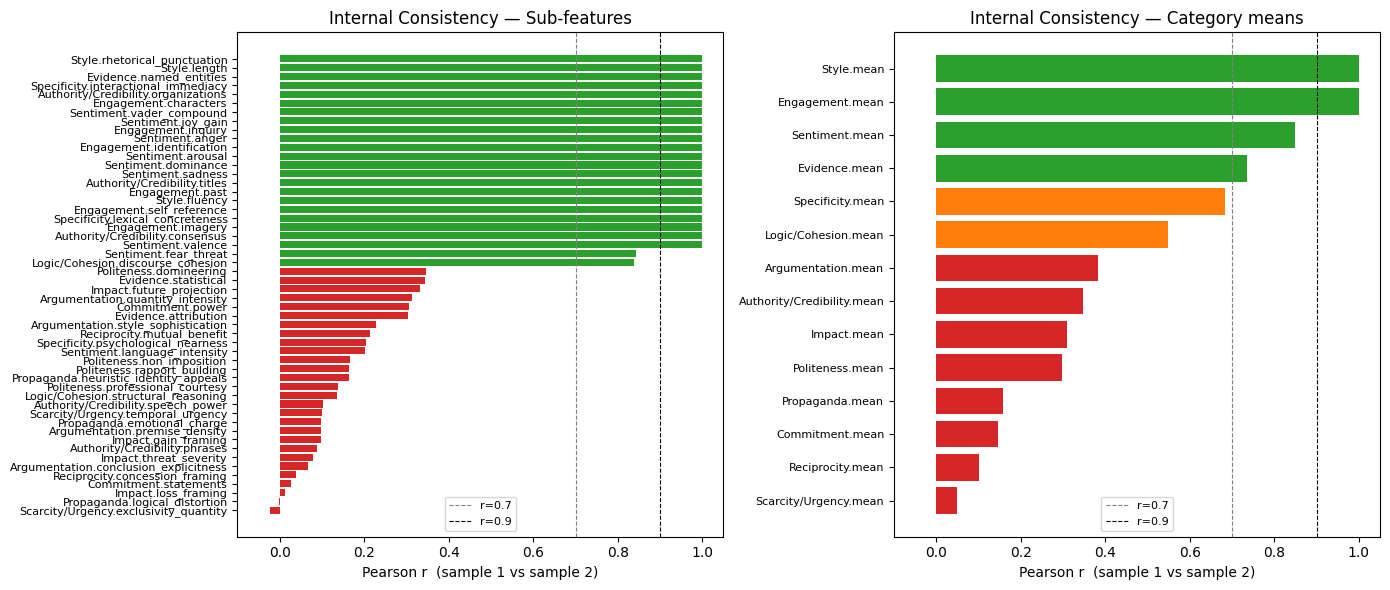

In [53]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, df_ic, title in [
    (axes[0], ic_sub,  "Sub-features"),
    (axes[1], ic_mean, "Category means"),
]:
    r_vals = df_ic["pearson_r"].dropna().sort_values()
    colors = ["#d62728" if r < 0.5 else "#ff7f0e" if r < 0.7 else "#2ca02c" for r in r_vals]
    ax.barh(range(len(r_vals)), r_vals.values, color=colors)
    ax.set_yticks(range(len(r_vals)))
    ax.set_yticklabels(r_vals.index, fontsize=8)
    ax.axvline(x=0.7, color="gray", linestyle="--", linewidth=0.8, label="r=0.7")
    ax.axvline(x=0.9, color="black", linestyle="--", linewidth=0.8, label="r=0.9")
    ax.set_xlim(-0.1, 1.05)
    ax.set_xlabel("Pearson r  (sample 1 vs sample 2)")
    ax.set_title(f"Internal Consistency — {title}")
    ax.legend(fontsize=8)

plt.tight_layout()
out_fig = os.path.join(_NOTEBOOK_DIR, "half_samples", "internal_consistency.pdf")
# plt.savefig(out_fig, bbox_inches="tight")
plt.show()
# print(f"Saved: {out_fig}")


In [56]:
import numpy as np
from scipy import stats

def correlate_feature_vectors_lexicon_only(df1: pd.DataFrame, df2: pd.DataFrame, label: str = ""):
    """
    Computes correlation between global feature means, excluding non-lexical 
    and zero-variance features to show the true stability of the lexicon.
    """
    # 1. Identify common columns
    common_cols = df1.columns.intersection(df2.columns)
    
    # 2. Identify which columns are "Genuinely Lexical"
    # We use a quick check: if the column is identical across both DFs, it's non-lexical
    lexical_cols = []
    for col in common_cols:
        v1, v2 = df1[col].values, df2[col].values
        
        # Calculate correlation for this specific feature
        if v1.std() < 1e-10 or v2.std() < 1e-10:
            continue # Skip zero-variance
            
        r_feature, _ = stats.pearsonr(v1, v2)
        
        # Only include if the feature actually changed (r < 1.0)
        if r_feature < 0.9999:
            lexical_cols.append(col)
    
    # 3. Calculate means only for those lexical columns
    vec1 = df1[lexical_cols].mean()
    vec2 = df2[lexical_cols].mean()
    
    # 4. Compute Pearson correlation between the two mean vectors
    if len(lexical_cols) < 2:
        print(f"=== Global Vector Correlation: {label} ===")
        print("  Not enough lexical features to correlate.")
        return np.nan, np.nan

    r_global, p_global = stats.pearsonr(vec1, vec2)
    
    print(f"=== Global Vector Correlation (Lexicon-Only): {label} ===")
    print(f"  Lexical Features compared: {len(lexical_cols)} (Filtered out {len(common_cols) - len(lexical_cols)} static/NaN)")
    print(f"  Pearson r: {r_global:.4f}")
    print(f"  p-value:   {p_global:.4e}")
    
    return r_global, p_global

# Execute the honest correlation
r_sub_h, p_sub_h = correlate_feature_vectors_lexicon_only(sub1, sub2, label="Sub-features")
r_mean_h, p_mean_h = correlate_feature_vectors_lexicon_only(mean1, mean2, label="Category means")

=== Global Vector Correlation (Lexicon-Only): Sub-features ===
  Lexical Features compared: 30 (Filtered out 25 static/NaN)
  Pearson r: 0.9000
  p-value:   1.3199e-11
=== Global Vector Correlation (Lexicon-Only): Category means ===
  Lexical Features compared: 12 (Filtered out 3 static/NaN)
  Pearson r: 0.9673
  p-value:   2.7951e-07
